# TensorFlow Computation Graphs

* A computation graph is a representation of a mathematical computation as a graph of operations.

* Data → Operations → Results

Example
* z=(a+b)×c

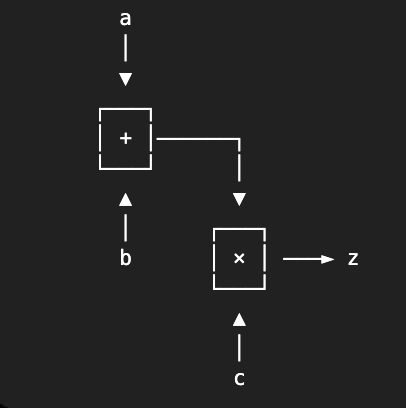

In [1]:
a = 10
b = 20
c = a + b
d = c * 5

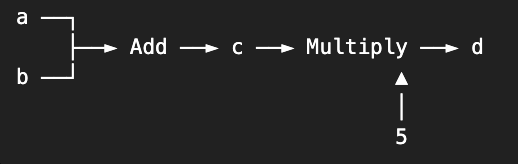

* tf.add()
* tf.multiply()
* tf.matmul()
* tf.reduce_sum()

In [1]:
import tensorflow as tf

a = tf.constant(10)
b = tf.constant(20)

c = a + b

print(c.numpy())

30


## Graph execution with tf.function

* The @tf.function decorator tells TensorFlow:

    "Trace this Python function and create a TensorFlow computation graph for it."

In [4]:
import tensorflow as tf

@tf.function
def add_numbers(a, b):
    return a + b


In [5]:
result = add_numbers(
    tf.constant(10),
    tf.constant(20)
)

print(result)

tf.Tensor(30, shape=(), dtype=int32)


Suppose:

    y=x**2

TensorFlow can track the operations used to calculate y.

Then TensorFlow can calculate:

        dy/dx=2x

using automatic differentiation.

In [6]:
import tensorflow as tf

x = tf.Variable(3.0)

with tf.GradientTape() as tape:
    y = x ** 2

gradient = tape.gradient(y, x)

print(gradient)

tf.Tensor(6.0, shape=(), dtype=float32)


In [7]:
@tf.function
def calculate(x):
    return x * 2 + 10

concrete_function = calculate.get_concrete_function(
    tf.TensorSpec(shape=[], dtype=tf.float32)
)

graph = concrete_function.graph

print(graph)

FuncGraph(name=calculate, id=4877170112)


In [8]:
for operation in graph.get_operations():
    print(operation.name, operation.type)

x Placeholder
mul/y Const
mul Mul
add/y Const
add AddV2
Identity Identity


In [22]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import TensorBoard
import datetime

# Load dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalize
x_train = x_train / 255.0
x_test = x_test / 255.0

# Create model
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

# Compile
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# Create log directory
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

# TensorBoard callback
tensorboard_callback = TensorBoard(
    log_dir=log_dir,
    histogram_freq=1
)

# Train
model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_data=(x_test, y_test),
    callbacks=[tensorboard_callback]
)

Epoch 1/5


/Users/anzarhussain/Documents/Deep Learning Tensorflow/myenv/lib/python3.13/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 734us/step - accuracy: 0.9258 - loss: 0.2580 - val_accuracy: 0.9609 - val_loss: 0.1376
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 667us/step - accuracy: 0.9656 - loss: 0.1150 - val_accuracy: 0.9694 - val_loss: 0.1001
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 733us/step - accuracy: 0.9757 - loss: 0.0793 - val_accuracy: 0.9721 - val_loss: 0.0906
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 688us/step - accuracy: 0.9821 - loss: 0.0586 - val_accuracy: 0.9755 - val_loss: 0.0855
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 730us/step - accuracy: 0.9860 - loss: 0.0467 - val_accuracy: 0.9785 - val_loss: 0.0733
